In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd

import psutil

from pyhdas.frequency import spectrogram, add_db, energy
from pyhdas.aggregate import quantile
from pyhdas.aragon import concat_raw_data, aragon_select_files

from datetime import timedelta

In [2]:
def load_get_energy(day, t_start, t_end, range):
    dir_data = Path(rf"data/{day}")
    extension = "bin"

    file_list = list(aragon_select_files(dir_data, t_start, t_end, extension=extension))
    ds_raw = concat_raw_data(file_list)
    t_start = t_start.tz_localize(None)
    t_end = t_end.tz_localize(None)
    ds_raw = ds_raw.sel(time=slice(t_start, t_end), position=np.arange(4220, 4270, 10))
    # ds_energy = energy(ds_raw, variable="strain", frequency_range=range)

    available_memory = psutil.virtual_memory().available / (1024 ** 3) 
    used_memory = psutil.virtual_memory().used / (1024 ** 3) 

    print(f"Available memory: {available_memory:.2f} GB")
    print(f"Used memory: {used_memory:.2f} GB")
    return ds_raw


In [3]:
t_start_26 = pd.Timestamp("2021-02-26 10:00:00+00")
t_end_26 = pd.Timestamp("2021-02-26 10:05:00+00")

t_start_25 = pd.Timestamp("2021-02-25 10:00:00+00")
t_end_25 = pd.Timestamp("2021-02-25 10:05:00+00")

t_start_19 = pd.Timestamp("2021-02-19 10:00:00+00")
t_end_19 = pd.Timestamp("2021-02-19 10:05:00+00")

In [4]:
range = (1,100)
event_day1_energy = load_get_energy("25", t_start_25, t_end_25, range)
event_day2_energy = load_get_energy("26", t_start_26, t_end_26, range)
normal_energy = load_get_energy("19", t_start_19, t_end_19, range)

Available memory: 14.89 GB
Used memory: 0.76 GB
Available memory: 15.02 GB
Used memory: 0.64 GB
Available memory: 15.04 GB
Used memory: 0.59 GB


In [6]:
t_start_26 = t_start_26.tz_localize(None)
t_end_26 = t_end_26.tz_localize(None)

t_start_25 = t_start_25.tz_localize(None)
t_end_25 = t_end_25.tz_localize(None)

t_start_19 = t_start_19.tz_localize(None)
t_end_19 = t_end_19.tz_localize(None)

In [7]:
events = pd.read_csv("events_table.csv", parse_dates=["start", "end"])
events = events[((events["start"] < t_end_25) & (events["end"] > t_start_25)) | ((events["start"] < t_end_26) & (events["end"] > t_start_26))]

In [8]:
def get_color(label):
    color_map = {
        "label_0": "gray",
        "label_1": "red",
        "label_2": "blue",
        "label_3": "green",
        "label_4": "yellow",
        "label_5": "orange",
        "label_6": "purple",
        "label_7": "magenta",
    }
    return color_map.get(label, "black")  

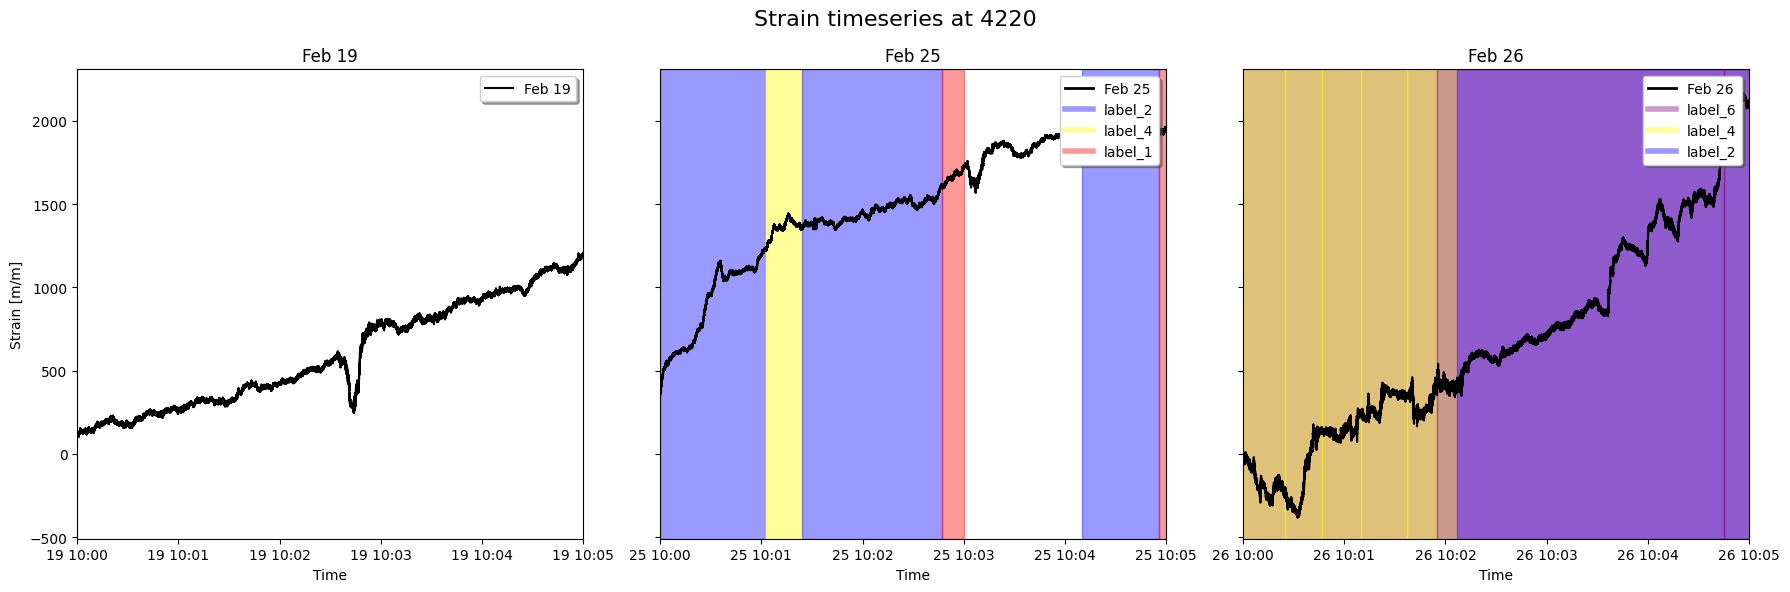

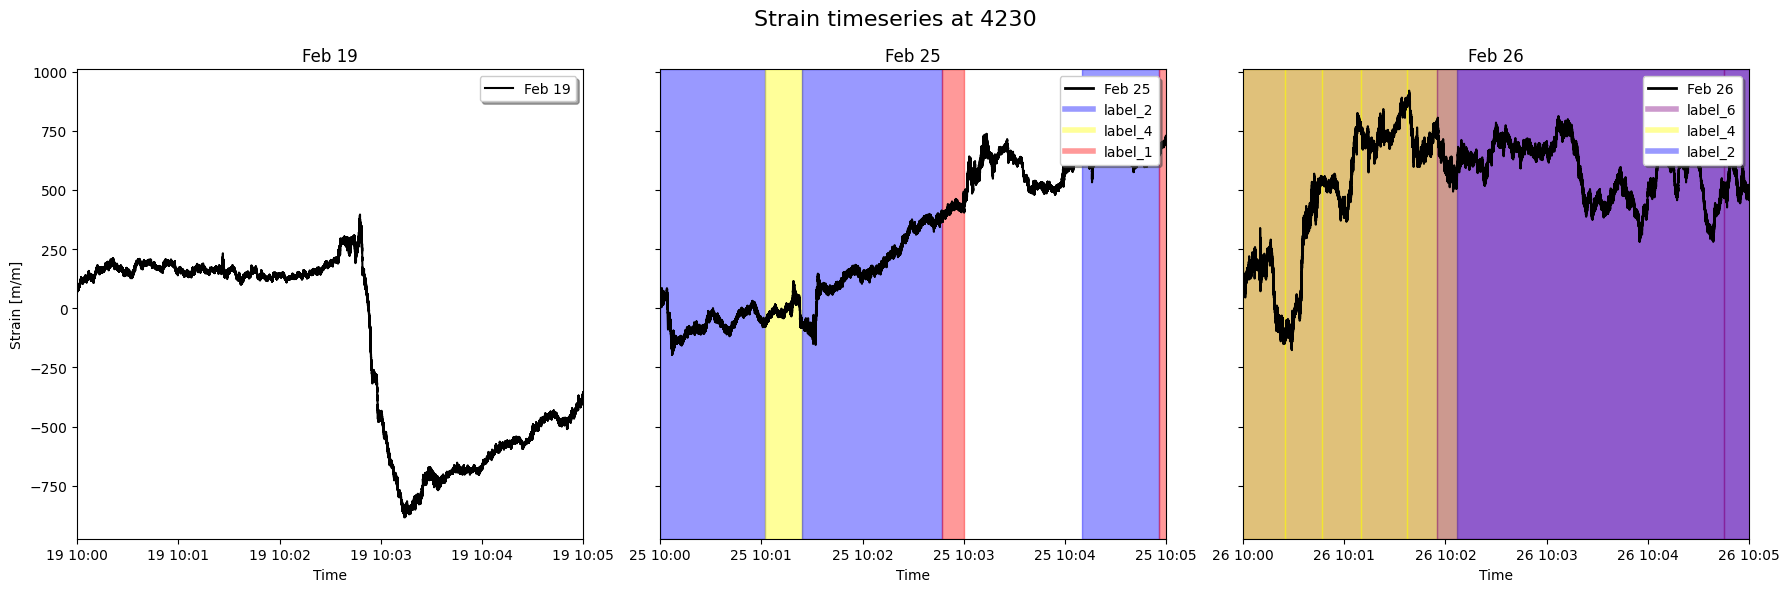

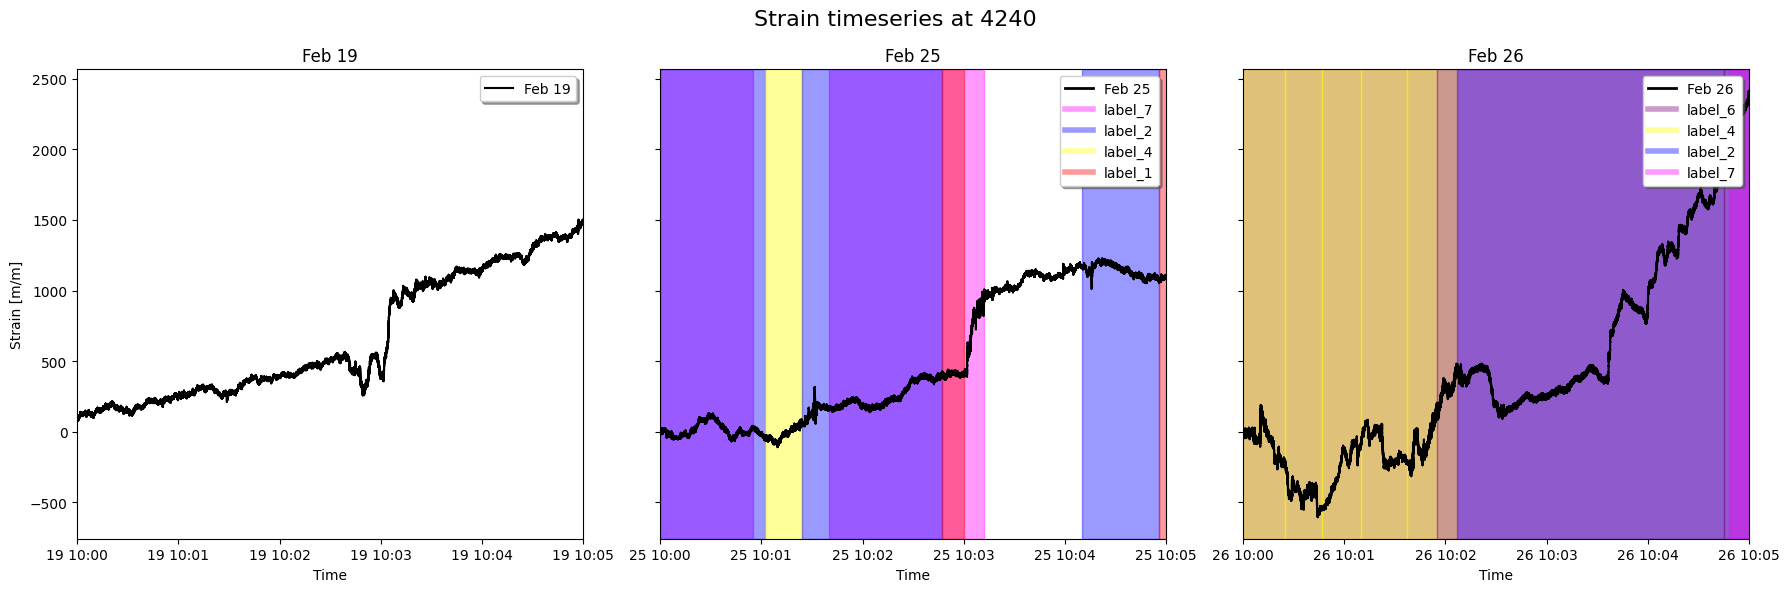

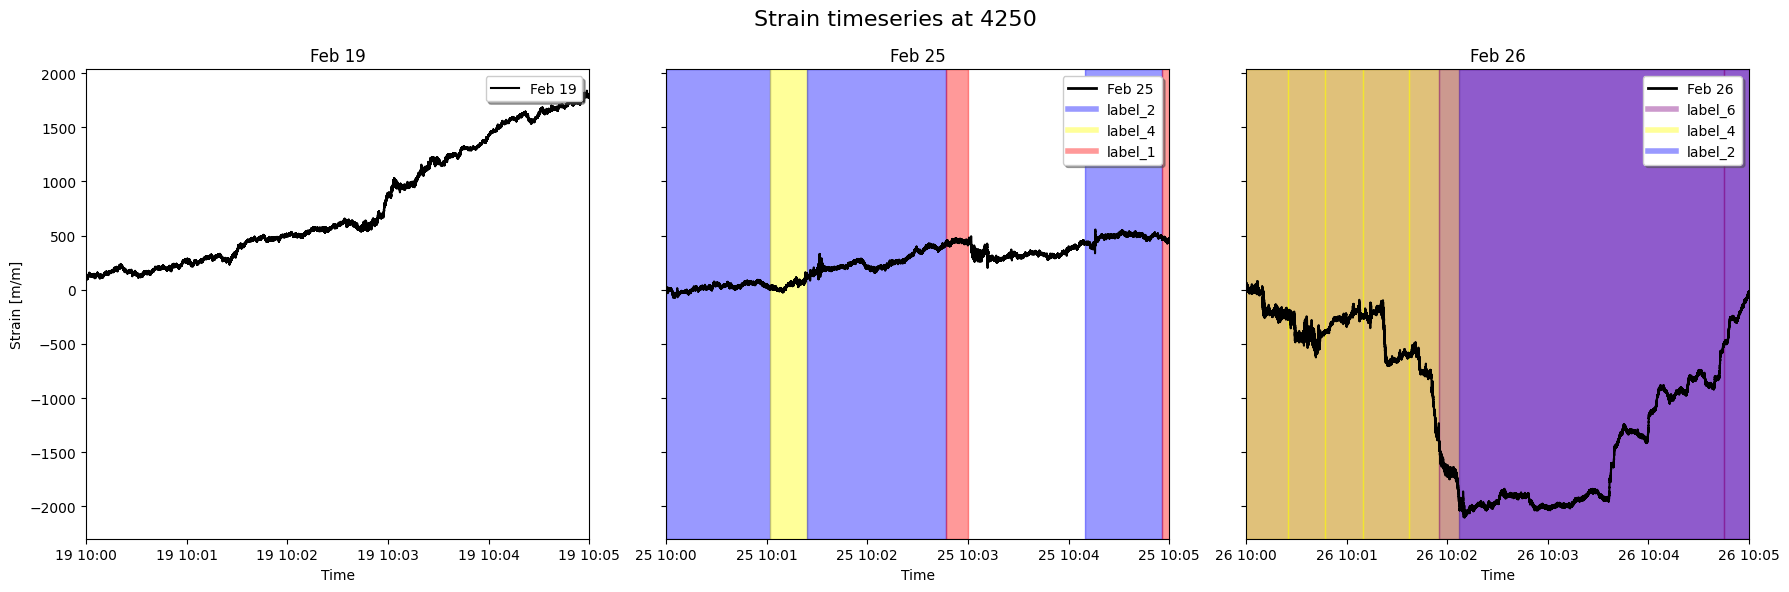

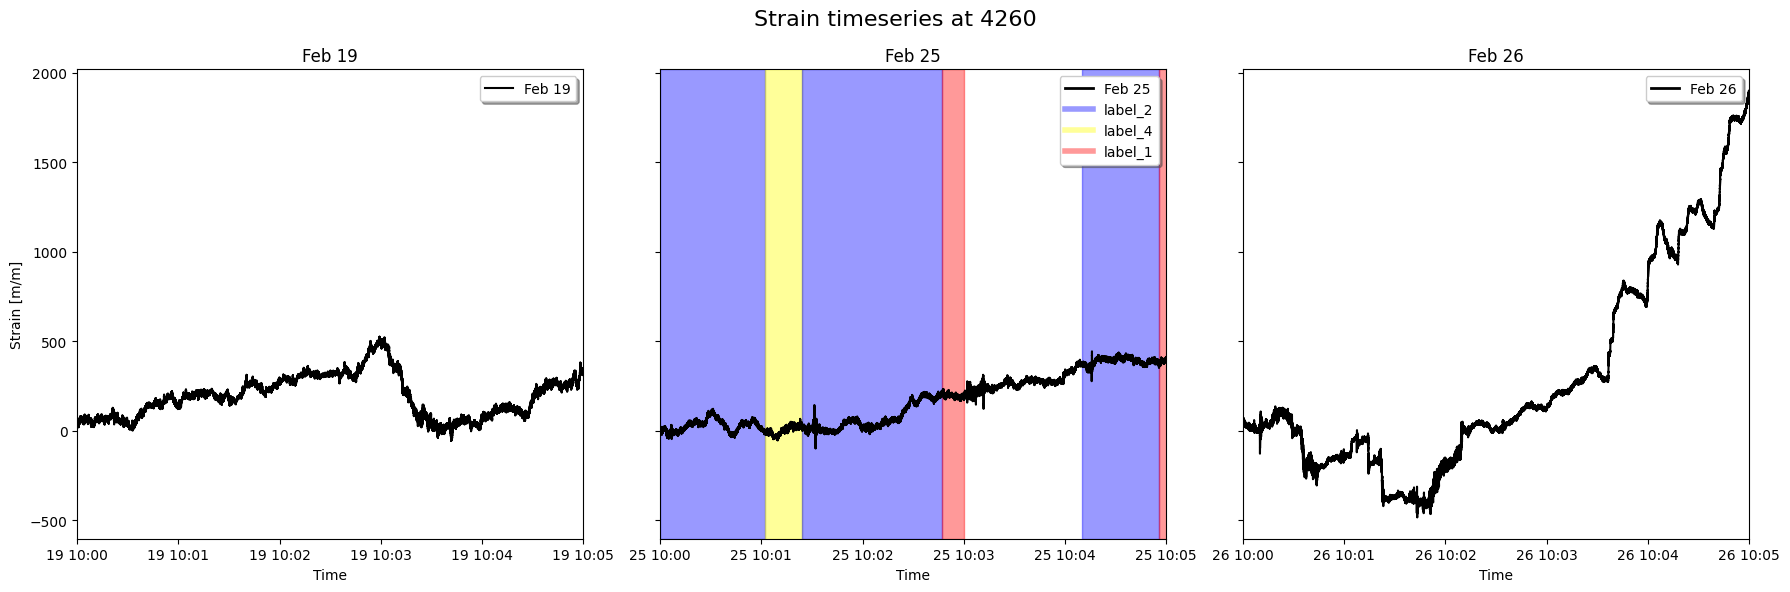

In [ ]:
def plot_energy_per_location(loc):
    # Filter events for this location
    loc_events = events[events['poi'].apply(lambda x: str(loc) in x)]

    # Define datasets and their time ranges
    datasets = [
        (normal_energy, "Feb 19", t_start_19, t_end_19),
        (event_day1_energy, "Feb 25", t_start_25, t_end_25),
        (event_day2_energy, "Feb 26",  t_start_26, t_end_26),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    for ax, (dataset, label, t_start, t_end) in zip(axes, datasets):
        # Plot the dataset
        ax.plot(dataset.time, dataset.sel(position=loc).strain, label=label, color="black")

        # Filter loc_events for the current time range
        current_loc_events = loc_events[(loc_events["start"] < t_end) & (loc_events["end"] > t_start)]

        # Add event spans for Feb 25 and Feb 26
        if label in ["Feb 25", "Feb 26"]:
            seen_labels = set()
            handles = []  
            for _, event in current_loc_events.iterrows():
                start, end, event_label = event["start"], event["end"], event["label_anon"]
                event_color = get_color(event_label)

                ax.axvspan(start, end, alpha=0.4, color=event_color)
                if event_label not in seen_labels:
                    handles.append(plt.Line2D([0], [0], color=event_color, lw=4, alpha=0.4, label=f"{event_label}"))
                    seen_labels.add(event_label)

            dataset_line = plt.Line2D([0], [0], color="black", lw=2, label=label)
            ax.legend(handles=[dataset_line] + handles, loc="upper right", fancybox=True, shadow=True)
        else:
            ax.legend(loc="upper right", fancybox=True, shadow=True)

        # Set axis limits and labels
        ax.set_xlim(t_start, t_end)
        # ax.set_ylim(0, 40)
        ax.set_title(label)
        ax.set_xlabel("Time")

    # Set shared Y-axis label
    axes[0].set_ylabel("Strain [m/m]")
    fig.suptitle(f"Strain timeseries at {loc}", fontsize=16)
    plt.tight_layout()
    plt.show()


# Loop through positions and plot
for pos in normal_energy.position:
    plot_energy_per_location(int(pos.item()))


In [ ]:
ds_spect = spectrogram(ds_raw, variable='strain')

In [ ]:
ds_soundlevel = ds_spect[["Pxx"]].sum(dim="freq")
ds_soundlevel = add_db(ds_soundlevel)

ds_soundlevel_low_pass = ds_spect[["Pxx"]].sel(freq=slice(1,100)).sum(dim="freq")
ds_soundlevel_low_pass = add_db(ds_soundlevel_low_pass)

ds_soundlevel_mid_pass = ds_spect[["Pxx"]].sel(freq=slice(100,500)).sum(dim="freq")
ds_soundlevel_mid_pass = add_db(ds_soundlevel_mid_pass)

ds_soundlevel_high_pass = ds_spect[["Pxx"]].sel(freq=slice(500,1000)).sum(dim="freq")
ds_soundlevel_high_pass = add_db(ds_soundlevel_high_pass)

In [ ]:
event_day1_energy

In [ ]:
fig,ax = plt.subplots(figsize=(15,6))
normal_energy.Pxx_dB.plot(x="position", y="time", ax=ax, vmin = 0, vmax = 40, cmap="magma")
ax.set_title(f"1-100 Hz soundlevel [dB], 19 Feb")
plt.show()

In [ ]:
fig,ax = plt.subplots(figsize=(15,6))
event_day1_energy.Pxx_dB.plot(x="position", y="time", ax=ax, vmin = 0, vmax = 40, cmap="magma")
ax.set_title(f"1-100 Hz soundlevel [dB], 25 Feb")
plt.show()

In [ ]:
fig,ax = plt.subplots(figsize=(15,6))
event_day2_energy.Pxx_dB.plot(x="position", y="time", ax=ax, vmin = 0, vmax = 40, cmap="magma")
ax.set_title(f"1-100 Hz soundlevel [dB], 26 Feb")
plt.show()

In [ ]:
import hvplot.xarray
event_day2_energy.Pxx_dB.hvplot(
    x="position", y="time", width=1200, height=600, clim=(0,40), cmap="magma", title="soundlevel [dB] over 500-1000 frequencies"
)